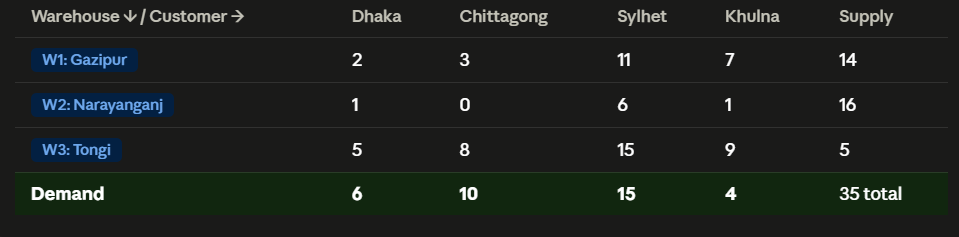

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import linprog

In [ ]:
cost_matrix = np.array([
    [2,  3, 11, 7],  # Gazipur
    [1,  0,  6, 1],  # Narayanganj
    [5,  8, 15, 9],  # Tongi
])


In [ ]:
supply  = np.array([14, 16, 5])   # warehouse capacity
demand  = np.array([6, 10, 15, 4]) # customer demand

In [ ]:
m,n=cost_matrix.shape
m,n

(3, 4)

## Objective Function

In [ ]:
c=cost_matrix.flatten()
print(c)

[ 2  3 11  7  1  0  6  1  5  8 15  9]


## Supply Constraints

In [ ]:
A_supply = np.zeros((m, m * n))
print(A_supply)

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [ ]:
for i in range(m):
    A_supply[i, i*n:(i+1)*n] = 1
print(A_supply)

[[1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1.]]


## Demand Constraints

In [ ]:
A_demand = np.zeros((n, m * n))
print(A_demand)

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [ ]:
for j in range(n):
    A_demand[j, j::n] = 1
print(A_demand)

[[1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1.]]


In [ ]:
A_eq=np.vstack([A_supply,A_demand])
print(A_eq)

[[1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1.]]


In [ ]:
b_eq = np.concatenate([supply, demand])
print(b_eq)

[14 16  5  6 10 15  4]


## Solve Problem

In [ ]:
result =linprog(
    c,
    A_eq=A_eq,
    b_eq=b_eq,
    bounds=[(0, None)] * (m * n),
    method='highs'
)

In [ ]:
print(result.x)

[ 1. 10.  3.  0.  0.  0. 12.  4.  5.  0.  0.  0.]


In [ ]:
allocation=result.x.reshape(m,n)
print(allocation)

[[ 1. 10.  3.  0.]
 [ 0.  0. 12.  4.]
 [ 5.  0.  0.  0.]]


In [ ]:
df=pd.DataFrame(allocation.round(1),
                index=['Gazipur','Narayanganj','Tongi'],
                columns=['Dhaka','CG','Syl','Kulna']
                )
print(df)

             Dhaka    CG   Syl  Kulna
Gazipur        1.0  10.0   3.0    0.0
Narayanganj    0.0   0.0  12.0    4.0
Tongi          5.0   0.0   0.0    0.0


In [ ]:
print(f"Min cost--> {result.fun}")

Min cost--> 166.0


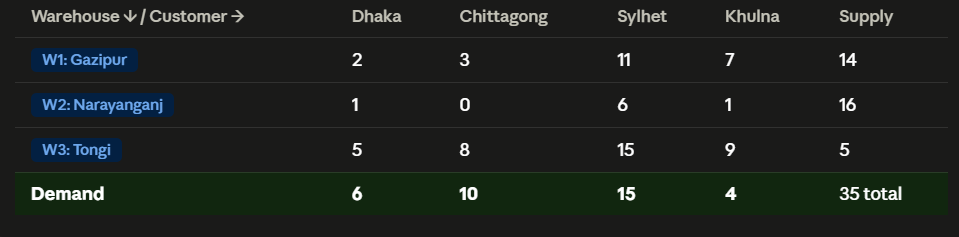

In [ ]:
z=1*2+10*3+3*11+12*6+4*1+5*5
print(z)

166
